# Interactive Denoising Lab — PandaOmron + GRPO LoRA — **Multi-Checkpoint** (v3)

Seed-sweep analysis run for a small set of GRPO LoRA checkpoints **plus the base
model (no LoRA)**, against one shared observation. Each checkpoint — and the base
model — produces **one composite figure** (large 3D EEF-trajectory panel +
per-component traces + mean±std spread).

## How this works — one model load, one feature encode

The Eagle VLM backbone is **frozen and never touched by LoRA** — LoRA only wraps
`nn.Linear` modules inside the DiT action head. That makes a single-notebook sweep
straightforward:

1. **Load the 3B model once** (Cell 2).
2. **Inject LoRA once** at `rank=16, alpha=32` and **do NOT merge** (Cell 2.5).
   Merging folds the adapter into the base weights *irreversibly*; we keep it as an
   overlay so each checkpoint's weights can be swapped in for its run — and so the
   adapter can be *disabled* to recover the base model.
3. **Encode backbone features once per observation** (inside `analyze_all_checkpoints`).
   Because LoRA never touches the backbone, the same `features` are valid input for
   every checkpoint and for the base model.
4. **Base model (no LoRA)**: `analyze_all_checkpoints` first runs a sweep with the
   injected adapters *disabled* (via `disabled_adapters`), so the DiT produces its
   pretrained velocity field. This needs no second model copy and is independent of
   whichever checkpoint happens to be loaded.
5. **For each checkpoint**: `load_lora_checkpoint(...)` overwrites the adapter's A/B
   matrices in place (fully replacing the previous checkpoint), then we run the
   100-seed sweep and draw **one composite figure per checkpoint**.

`load_lora_checkpoint` does a strict two-sided key + shape check, so a checkpoint
trained with a different rank/target-module set would hard-fail here rather than
silently degrade. All checkpoints below share the GRPO defaults
(`rank=16, alpha=32`, `DEFAULT_LORA_TARGET_MODULES`).

> ⚠️ The LoRA **scale** (`alpha / rank`) comes from the `apply_lora_to_dit` call,
> *not* from the checkpoint file. If any checkpoint was trained with a different
> `alpha`, set `LORA_ALPHA` to match it before loading — otherwise the adapter is
> applied at the wrong scale.

To analyze a different observation, just call
`analyze_all_checkpoints("/path/to/other.npz")` in a new cell — no reload needed.

In [1]:
# Cell 1: Imports + config
import sys, os
import numpy as np
import torch
import matplotlib.pyplot as plt

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from scripts.denoising_lab.denoising_lab import DenoisingLab, TrajectoryVisualizer

MODEL_PATH = "nvidia/GR00T-N1.6-3B"
EMBODIMENT_TAG = "robocasa_panda_omron"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Observation .npz captured by interactive_rollout.py. Change this (or just call
# analyze_all_checkpoints("...") with another path) for any other observation.
OBS_PATH = "/home/ubuntu/results/npz_save_CoffeeServeMug_v2/ep000_step010.npz"

EEF_KEY = "end_effector_position"
N_SEEDS = 100              # seeds per checkpoint (matches v1 Cell 11)

# LoRA config — MUST match what the checkpoints were trained with.
# (GRPOConfig defaults; all checkpoints below use these.)
LORA_RANK = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.0

# Also sweep the BASE model (no LoRA) by disabling the injected adapter. Produces the
# same composite figure and an entry in the cross-checkpoint summary. See Cell 4.
INCLUDE_BASE_MODEL = True

# Checkpoints to compare (relative to REPO_ROOT). Each dir holds lora_weights.pt.
CHECKPOINTS = [
    "grpo_data/overfit_step10_v5_lr5.9e-5_PAWS_plam0.25_nlam0.05_loclip0.08_hiclip0.2_kll0.1_klb0.1_tratio1.75_mbrenorm_BMPARD_nojitterpair_1epoch_gs12_ng4_mb64/iter_0011/",
    "grpo_data/overfit_step10_v5_lr5.9e-5_PAWS_plam0.25_nlam0.05_loclip0.08_hiclip0.2_kll0.1_klb0.1_tratio1.75_mbrenorm_BMPARD_nojitterpair_1epoch_gs12_ng4_mb64/iter_0012/",
]

n_runs = len(CHECKPOINTS) + (1 if INCLUDE_BASE_MODEL else 0)
print(f"Device: {DEVICE}")
print(f"{len(CHECKPOINTS)} checkpoints"
      f"{' + base model' if INCLUDE_BASE_MODEL else ''} = {n_runs} runs, {N_SEEDS} seeds each")

/home/ubuntu/my_Isaac-GR00T/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
2 checkpoints + base model = 3 runs, 100 seeds each


In [2]:
# Cell 2: Load model (once)
lab = DenoisingLab(MODEL_PATH, EMBODIMENT_TAG, device=DEVICE)
print(f"Model loaded. Action horizon: {lab.action_horizon}, Action dim: {lab.action_dim}")
print(f"Inference timesteps: {lab.num_inference_timesteps}, Timestep buckets: {lab.num_timestep_buckets}")

/usr/bin/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status
/usr/bin/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status
/home/ubuntu/my_Isaac-GR00T/.venv/lib/python3.10/site-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


Tune backbone llm: False
Tune backbone visual: False
Backbone trainable parameter: model.language_model.model.layers.12.self_attn.q_proj.weight
Backbone trainable parameter: model.language_model.model.layers.12.self_attn.k_proj.weight
Backbone trainable parameter: model.language_model.model.layers.12.self_attn.v_proj.weight
Backbone trainable parameter: model.language_model.model.layers.12.self_attn.o_proj.weight
Backbone trainable parameter: model.language_model.model.layers.12.self_attn.q_norm.weight
Backbone trainable parameter: model.language_model.model.layers.12.self_attn.k_norm.weight
Backbone trainable parameter: model.language_model.model.layers.12.mlp.gate_proj.weight
Backbone trainable parameter: model.language_model.model.layers.12.mlp.up_proj.weight
Backbone trainable parameter: model.language_model.model.layers.12.mlp.down_proj.weight
Backbone trainable parameter: model.language_model.model.layers.12.input_layernorm.weight
Backbone trainable parameter: model.language_mode

/home/ubuntu/my_Isaac-GR00T/gr00t/model/modules/dit.py:205: FutureWarning: Accessing config attribute `compute_dtype` directly via 'AlternateVLDiT' object attribute is deprecated. Please access 'compute_dtype' over 'AlternateVLDiT's config object instead, e.g. 'unet.config.compute_dtype'.
  embedding_dim=self.inner_dim, compute_dtype=self.compute_dtype
/home/ubuntu/my_Isaac-GR00T/gr00t/model/modules/dit.py:236: FutureWarning: Accessing config attribute `output_dim` directly via 'AlternateVLDiT' object attribute is deprecated. Please access 'output_dim' over 'AlternateVLDiT's config object instead, e.g. 'unet.config.output_dim'.
  self.proj_out_2 = nn.Linear(self.inner_dim, self.output_dim)


Total number of DiT parameters:  1091722240
Using AlternateVLDiT for diffusion model


`use_fast` is set to `True` but the image processor class does not have a fast version.  Falling back to the slow version.


Tune action head projector: True
Tune action head diffusion model: True
Tune action head vlln: True


Loading checkpoint shards: 100%|██████████| 2/2 [00:04<00:00,  2.41s/it]


Model loaded. Action horizon: 50, Action dim: 128
Inference timesteps: 4, Timestep buckets: 1000


In [3]:
# Cell 2.5: Inject LoRA ONCE into the DiT — do NOT load a checkpoint yet, do NOT merge.
#
# We inject the adapter shell here and reuse it for every checkpoint: the loop below
# calls load_lora_checkpoint(...) to swap each checkpoint's A/B matrices into these
# same modules. We deliberately skip merge_lora_weights() — merging is irreversible
# and would bake one checkpoint into the base weights, making it impossible to cleanly
# load the next one OR to disable the adapter for the base-model run. The cost is a
# small per-forward LoRA matmul (a few extra seconds per 100-seed sweep), which is fine.
import sys as _sys
_grpo_dir = os.path.join(REPO_ROOT, "scripts", "grpo")
if _grpo_dir not in _sys.path:
    _sys.path.insert(0, _grpo_dir)

# disabled_adapters: context manager that zeros the LoRA contribution for the base-model
# sweep — the DiT then produces its pretrained velocity field, no second copy in VRAM.
from lora_dit import (
    apply_lora_to_dit,
    load_lora_checkpoint,
    disabled_adapters,
    print_trainable_params,
)

apply_lora_to_dit(lab.model, rank=LORA_RANK, alpha=LORA_ALPHA, dropout=LORA_DROPOUT)

# Pin the freshly-injected LoRA Linears to the DiT's device/dtype. Done ONCE:
# load_lora_checkpoint copies weights in place via load_state_dict, so loaded adapters
# inherit this device/dtype on every subsequent load (no re-.to() needed).
lab.model.action_head.model.to(device=lab.device, dtype=lab.dtype)
lab.model.eval()

print_trainable_params(lab.model)  # ~14.5M LoRA params, rest frozen

Trainable params: 14,532,608 / 3,301,141,440 (0.44%)
  LoRA params:  ~14,532,608
  Frozen params: ~3,286,608,832


{'trainable': 14532608, 'total': 3301141440, 'percentage': 0.44022978912409155}

## Per-checkpoint seed sweep

`run_seed_sweep` reproduces v1 Cell 11 ("Compare seeds") for a single
`(features, checkpoint)` pair, but draws **one composite figure** per adapter:

```
+------------+  +----+ +----+ +----+   <- X/Y/Z component traces (100 seeds)
|            |  +----+ +----+ +----+
|  3D EEF    |
|  traj      |  +----+ +----+ +----+   <- x/y/z mean ± 1 std spread
|            |  +----+ +----+ +----+
+------------+
```

`analyze_all_checkpoints` drives it across the base model (adapters disabled) and
every checkpoint for one observation, encoding backbone features just once.

In [4]:
# Cell 3: run_seed_sweep — reproduces v1 Cell 11 ("Compare seeds") for one
# (features, checkpoint) pair. Sweeps n_seeds noise seeds through the 4-step denoiser,
# decodes each to an EEF trajectory, prints per-component spread stats, then draws ONE
# composite figure: a large 3D EEF-trajectory panel (left), the X/Y/Z component traces
# (top-right), and the x/y/z mean+-std spread (bottom-right). Returns a stats dict for
# the cross-checkpoint summary.
def run_seed_sweep(lab, features, label, n_seeds=N_SEEDS, eef_key=EEF_KEY, show_plots=True):
    viz_seeds = TrajectoryVisualizer()
    for seed in range(n_seeds):
        r = lab.denoise(features, seed=seed)
        d = lab.decode_raw_actions(r.action_pred, features.states)
        viz_seeds.add_trajectory(d, f"seed={seed}", eef_key=eef_key)

    # Stack all trajectories: shape (n_seeds, T+1, 3)
    all_pos = np.stack([t["positions"] for t in viz_seeds.trajectories])
    mean = all_pos.mean(axis=0)   # (T+1, 3)
    var = all_pos.var(axis=0)     # (T+1, 3)
    rng = all_pos.max(axis=0) - all_pos.min(axis=0)  # (T+1, 3)

    comp = ["x", "y", "z"]
    print("Across all timesteps:")
    for i, l in enumerate(comp):
        print(f"  {l}: mean={mean[:, i].mean():.4f}, \tvar={var[:, i].mean():.4f}, \tstd={np.sqrt(var[:, i]).mean():.4f}, \trange={rng[:, i].mean():.4f}")
    print("Across final timestep only:")
    for i, l in enumerate(comp):
        print(f"  {l}: mean={mean[-1, i]:.4f}, \tvar={var[-1, i]:.4f}, \tstd={np.sqrt(var[-1, i]):.4f}, \trange={rng[-1, i]:.4f}")

    if show_plots:
        # ONE composite figure per adapter: 3D (left, full height) + 2x3 grid (right).
        comp_up = ["X", "Y", "Z"]
        fig = plt.figure(figsize=(20, 8), constrained_layout=True)
        gs = fig.add_gridspec(2, 5)

        # Left: 3D EEF trajectory — one line per seed, shared start (^) and mean end (square).
        ax3d = fig.add_subplot(gs[:, 0:2], projection="3d")
        for s in range(all_pos.shape[0]):
            p = all_pos[s]
            ax3d.plot(p[:, 0], p[:, 1], p[:, 2], "-", color="C0", linewidth=0.6, alpha=0.4)
        ax3d.scatter(*all_pos[0, 0], marker="^", s=60, color="k", zorder=5)
        ax3d.scatter(*mean[-1], marker="s", s=60, color="r", zorder=5)
        # Equal aspect via bounding box (mirrors TrajectoryVisualizer.plot_eef_3d).
        flat = all_pos.reshape(-1, 3)
        bmin, bmax = flat.min(axis=0), flat.max(axis=0)
        mid = (bmin + bmax) / 2
        half = (bmax - bmin).max() / 2
        if half < 1e-8:
            half = 0.01
        ax3d.set_xlim(mid[0] - half, mid[0] + half)
        ax3d.set_ylim(mid[1] - half, mid[1] + half)
        ax3d.set_zlim(mid[2] - half, mid[2] + half)
        ax3d.set_xlabel("X"); ax3d.set_ylabel("Y"); ax3d.set_zlabel("Z")
        ax3d.set_title(f"3D EEF trajectory ({n_seeds} seeds)", fontsize=10)

        # Top-right: raw X/Y/Z component traces (one line per seed).
        for i in range(3):
            axc = fig.add_subplot(gs[0, 2 + i])
            axc.plot(all_pos[:, :, i].T, color="C0", linewidth=0.5, alpha=0.25)
            axc.set_title(f"EEF {comp_up[i]} ({n_seeds} seeds)", fontsize=9)
            axc.set_xlabel("timestep", fontsize=8)
            axc.grid(True, alpha=0.3)

        # Bottom-right: x/y/z mean +- 1 std spread.
        for i in range(3):
            axs = fig.add_subplot(gs[1, 2 + i])
            std_i = np.sqrt(var[:, i])
            axs.plot(mean[:, i], color="C1", label="mean")
            axs.fill_between(range(mean.shape[0]), mean[:, i] - std_i, mean[:, i] + std_i,
                             alpha=0.3, color="C1", label="±1 std")
            axs.set_title(f"{comp[i]} mean±std", fontsize=9)
            axs.set_xlabel("timestep", fontsize=8)
            axs.grid(True, alpha=0.3)
            if i == 0:
                axs.legend(fontsize=7)

        fig.suptitle(f"Seed spread — {label}", fontsize=13)
        plt.show()

    return {
        "label": label,
        "mean": mean,
        "var": var,
        "range": rng,
        "final_std": np.sqrt(var[-1]),          # (3,) std at final timestep
        "mean_std": np.sqrt(var).mean(axis=0),  # (3,) std averaged over timesteps
    }

In [5]:
# Cell 4: analyze_all_checkpoints — encode one observation, then run the seed sweep
# for the base model (adapters disabled) and every checkpoint in CHECKPOINTS. Features
# are encoded ONCE (the backbone is LoRA-free); each checkpoint's adapter is loaded into
# the already-injected DiT, fully overwriting the previous checkpoint's A/B matrices.
def analyze_all_checkpoints(obs_path, n_seeds=N_SEEDS, show_obs=True, include_base=INCLUDE_BASE_MODEL):
    obs = DenoisingLab.load_observation(obs_path)
    print("Observation:", obs_path)
    print("Task:", obs["annotation.human.action.task_description"])
    if show_obs:
        DenoisingLab.plot_camera_views(obs, figsize=(14, 4))
        plt.suptitle(f"Camera views — {os.path.basename(obs_path)}", fontsize=12)
        plt.show()

    features = lab.encode_features_from_sim_obs(obs)  # EXPENSIVE — once per obs
    print(f"Backbone features: {features.backbone_features.shape}")

    results = {}

    # Base model (no LoRA): disable the injected adapters so the DiT produces its
    # pretrained velocity field. Independent of whichever checkpoint is currently
    # loaded, so we run it FIRST — before touching any adapter weights.
    if include_base:
        label = "BASE (no LoRA)"
        print("\n" + "=" * 90)
        print(f"CHECKPOINT: {label}")
        print("=" * 90)
        with disabled_adapters(lab.model.action_head.model):
            results[label] = run_seed_sweep(lab, features, label, n_seeds=n_seeds)

    for ckpt_rel in CHECKPOINTS:
        ckpt = os.path.join(REPO_ROOT, ckpt_rel)
        label = ckpt_rel.replace("grpo_data/", "")
        print("\n" + "=" * 90)
        print(f"CHECKPOINT: {label}")
        print("=" * 90)
        load_lora_checkpoint(lab.model, ckpt)  # overwrites the previous adapter in place
        results[label] = run_seed_sweep(lab, features, label, n_seeds=n_seeds)
    return features, results

Observation: /home/ubuntu/results/npz_save_CoffeeServeMug_v2/ep000_step010.npz
Task: ('pick the mug from under the coffee machine dispenser and place it on the counter',)


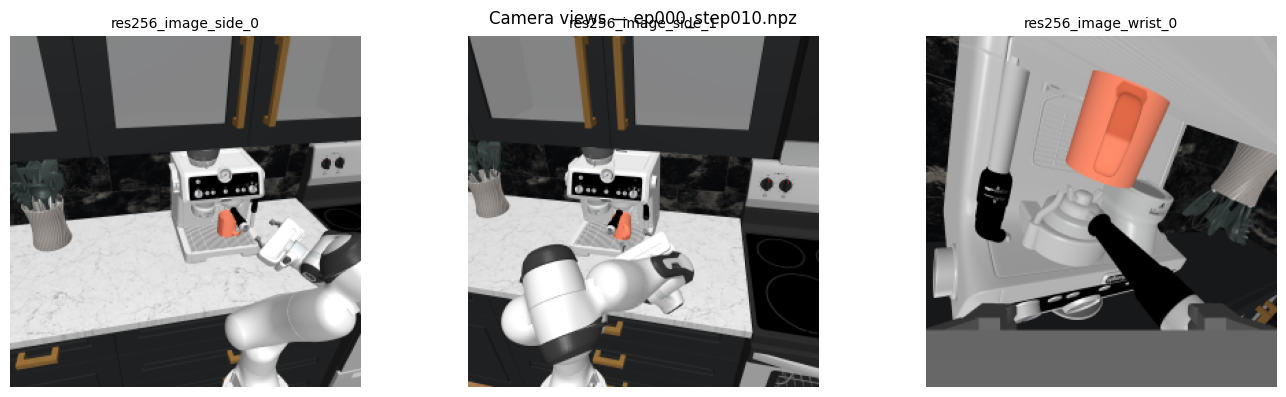

Backbone features: torch.Size([1, 295, 2048])

CHECKPOINT: BASE (no LoRA)
Across all timesteps:
  x: mean=2.6243, 	var=0.0031, 	std=0.0516, 	range=0.3006
  y: mean=1.0387, 	var=0.0039, 	std=0.0571, 	range=0.2934
  z: mean=-1.7029, 	var=0.0021, 	std=0.0409, 	range=0.2009
Across final timestep only:
  x: mean=5.0635, 	var=0.0061, 	std=0.0784, 	range=0.5352
  y: mean=1.4611, 	var=0.0108, 	std=0.1041, 	range=0.5761
  z: mean=-3.0722, 	var=0.0078, 	std=0.0884, 	range=0.4404


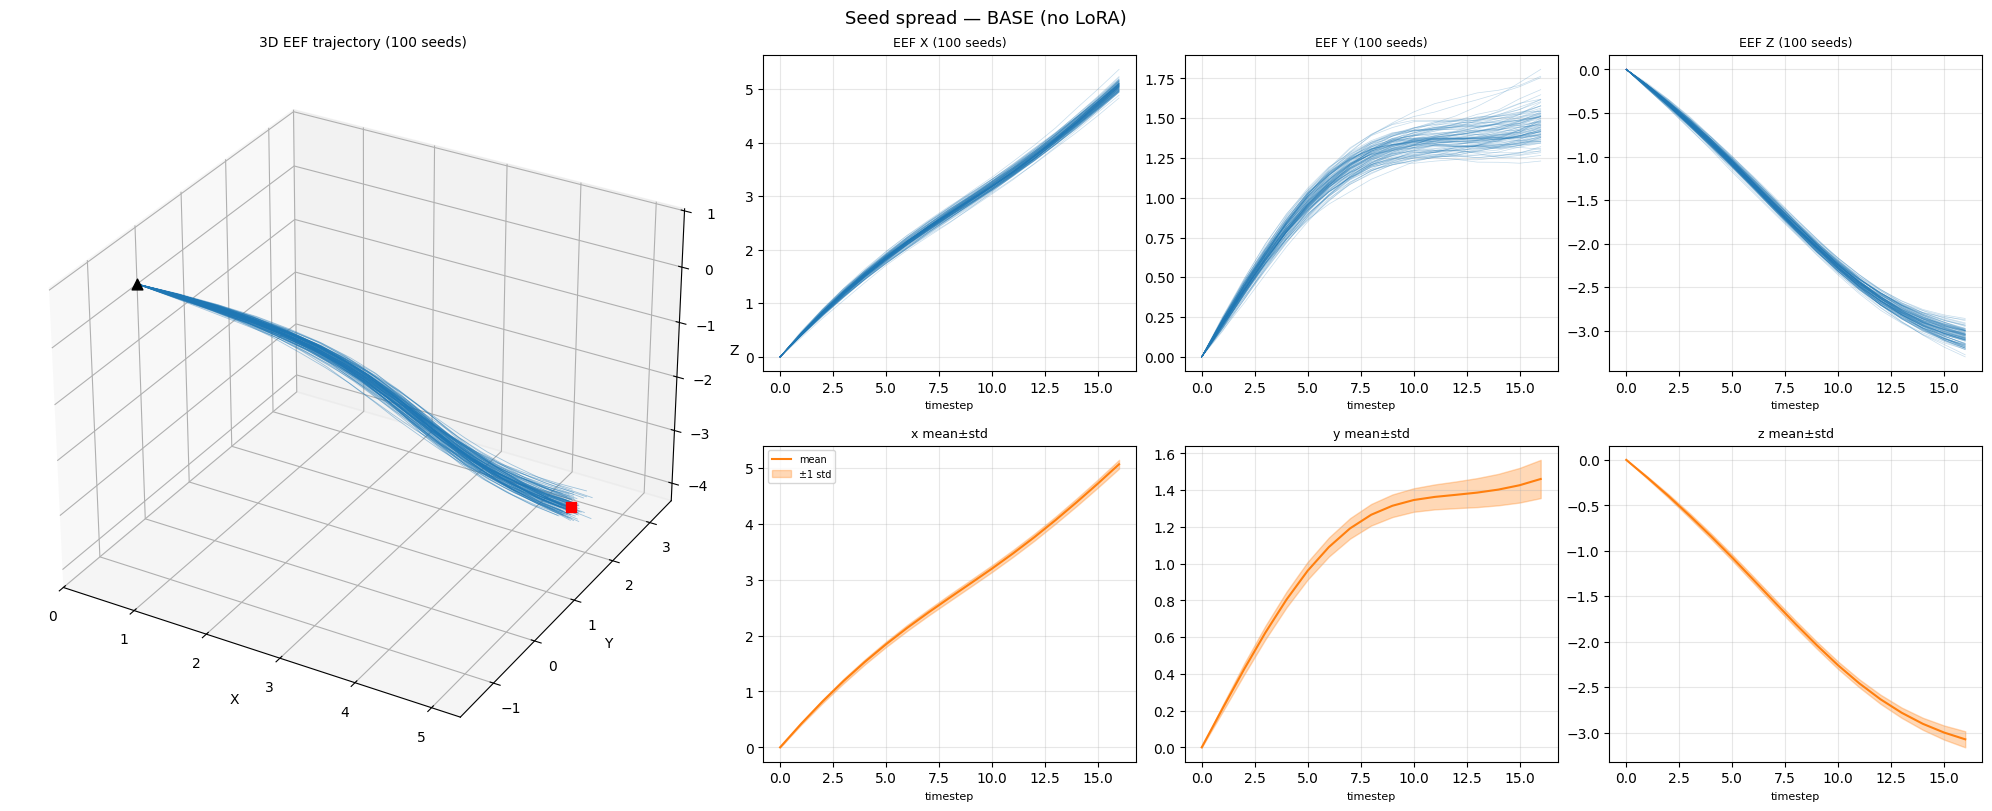


CHECKPOINT: overfit_step10_v5_lr5.9e-5_PAWS_plam0.25_nlam0.05_loclip0.08_hiclip0.2_kll0.1_klb0.1_tratio1.75_mbrenorm_BMPARD_nojitterpair_1epoch_gs12_ng4_mb64/iter_0011/
  Loaded 388 LoRA parameters from /home/ubuntu/my_Isaac-GR00T/grpo_data/overfit_step10_v5_lr5.9e-5_PAWS_plam0.25_nlam0.05_loclip0.08_hiclip0.2_kll0.1_klb0.1_tratio1.75_mbrenorm_BMPARD_nojitterpair_1epoch_gs12_ng4_mb64/iter_0011
Across all timesteps:
  x: mean=3.4032, 	var=0.1385, 	std=0.3417, 	range=1.8980
  y: mean=1.4662, 	var=0.1227, 	std=0.3165, 	range=1.8503
  z: mean=-2.2453, 	var=0.0731, 	std=0.2468, 	range=1.3083
Across final timestep only:
  x: mean=6.3019, 	var=0.2943, 	std=0.5425, 	range=3.5273
  y: mean=2.0423, 	var=0.3046, 	std=0.5519, 	range=3.1736
  z: mean=-4.1411, 	var=0.1830, 	std=0.4278, 	range=2.2988


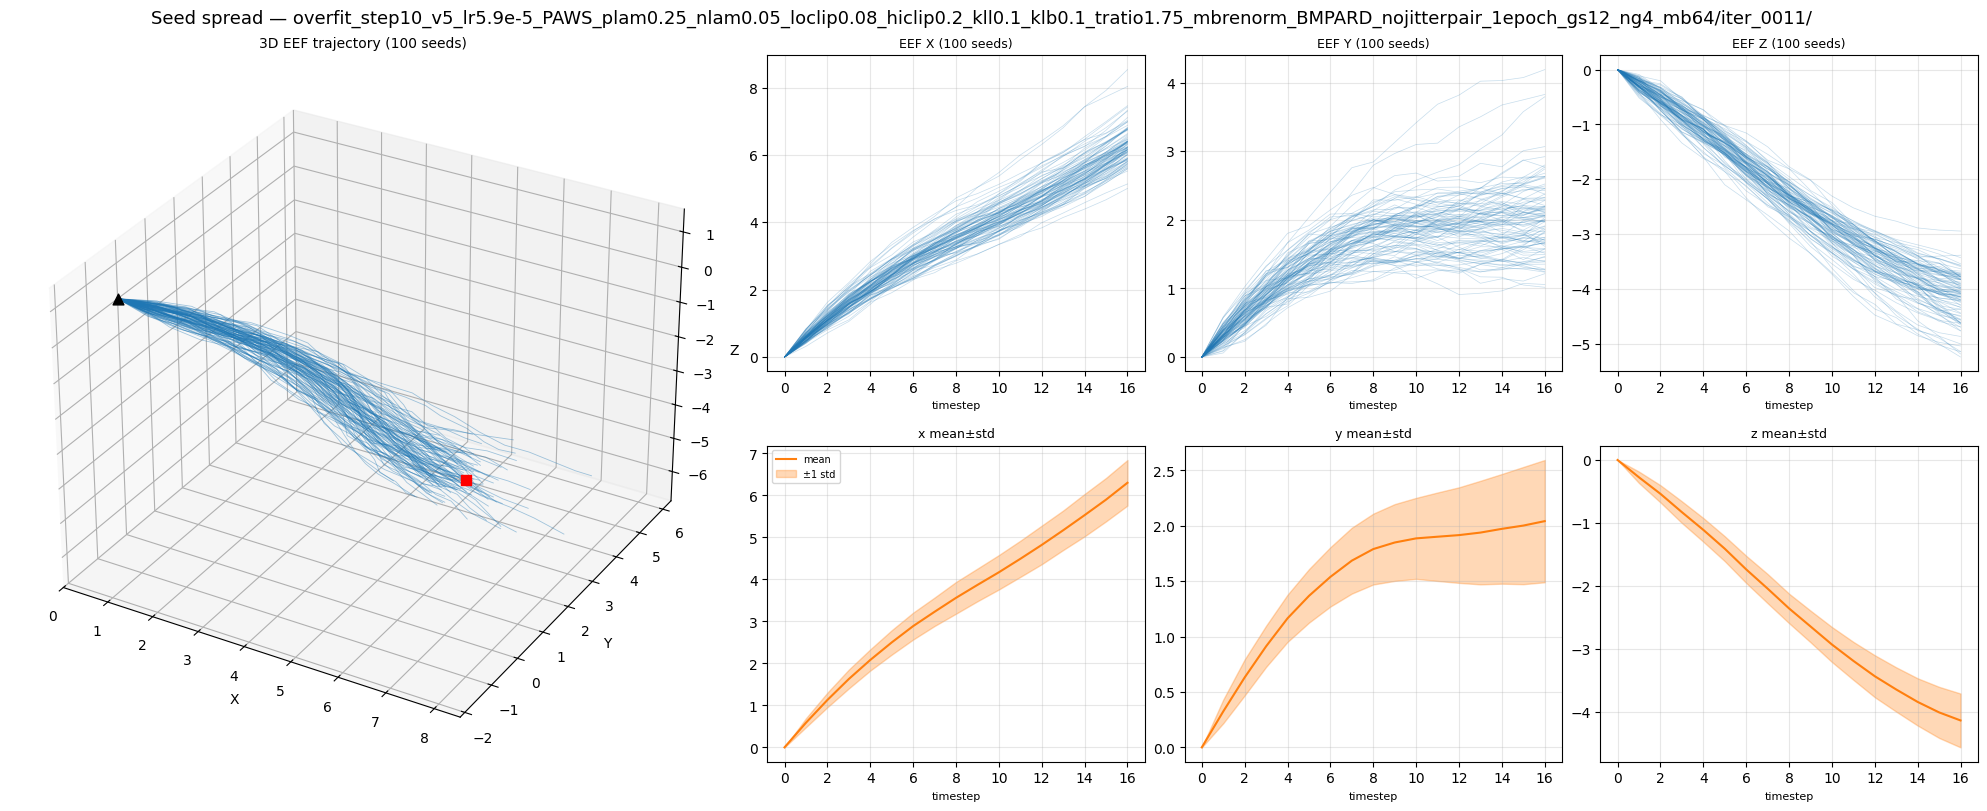


CHECKPOINT: overfit_step10_v5_lr5.9e-5_PAWS_plam0.25_nlam0.05_loclip0.08_hiclip0.2_kll0.1_klb0.1_tratio1.75_mbrenorm_BMPARD_nojitterpair_1epoch_gs12_ng4_mb64/iter_0012/
  Loaded 388 LoRA parameters from /home/ubuntu/my_Isaac-GR00T/grpo_data/overfit_step10_v5_lr5.9e-5_PAWS_plam0.25_nlam0.05_loclip0.08_hiclip0.2_kll0.1_klb0.1_tratio1.75_mbrenorm_BMPARD_nojitterpair_1epoch_gs12_ng4_mb64/iter_0012
Across all timesteps:
  x: mean=3.4398, 	var=0.1508, 	std=0.3566, 	range=1.9722
  y: mean=1.5117, 	var=0.1334, 	std=0.3306, 	range=1.9332
  z: mean=-2.2791, 	var=0.0780, 	std=0.2550, 	range=1.3543
Across final timestep only:
  x: mean=6.3618, 	var=0.3210, 	std=0.5666, 	range=3.6777
  y: mean=2.1017, 	var=0.3291, 	std=0.5736, 	range=3.2922
  z: mean=-4.2044, 	var=0.1945, 	std=0.4410, 	range=2.4092


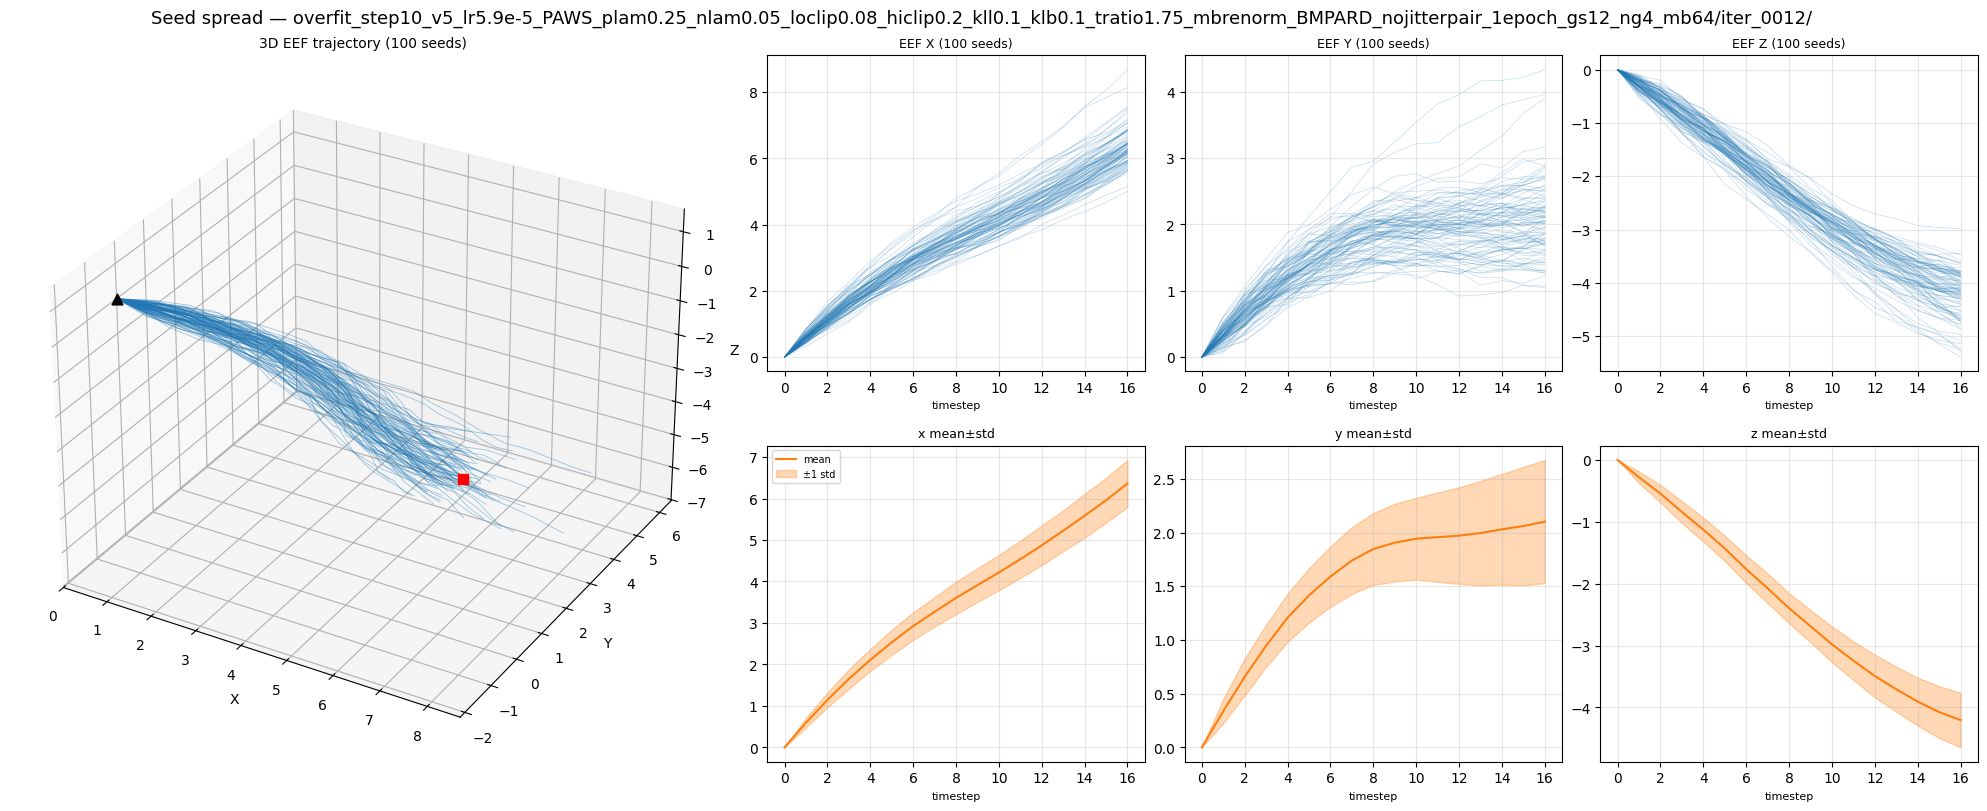

In [6]:
# Cell 5: Run the full comparison (base model + all checkpoints) for OBS_PATH.
# OBS_PATH is set to ...ep000_step010.npz in Cell 1. Re-run with a different path for
# any other observation, e.g. analyze_all_checkpoints("/path/to/other.npz").
_features, results = analyze_all_checkpoints(OBS_PATH)

## Cross-checkpoint summary

Final-timestep EEF-position std across the seeds, per checkpoint (and the base model).
Higher std = more action diversity driven by the initial noise; lower std = the
checkpoint has become more "decisive" / peaked for this observation.

checkpoint                                              std_x    std_y    std_z      mean
BASE (no LoRA)                                         0.0784   0.1041   0.0884    0.0903
overfit_step10_v5_lr5.9e-5_PAWS_plam0.25_nlam0.05_loclip0.08_hiclip0.2_kll0.1_klb0.1_tratio1.75_mbrenorm_BMPARD_nojitterpair_1epoch_gs12_ng4_mb64/iter_0011/   0.5425   0.5519   0.4278    0.5074
overfit_step10_v5_lr5.9e-5_PAWS_plam0.25_nlam0.05_loclip0.08_hiclip0.2_kll0.1_klb0.1_tratio1.75_mbrenorm_BMPARD_nojitterpair_1epoch_gs12_ng4_mb64/iter_0012/   0.5666   0.5736   0.4410    0.5271


/mnt/scratch/tmp/ipykernel_11494/2195502949.py:19: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


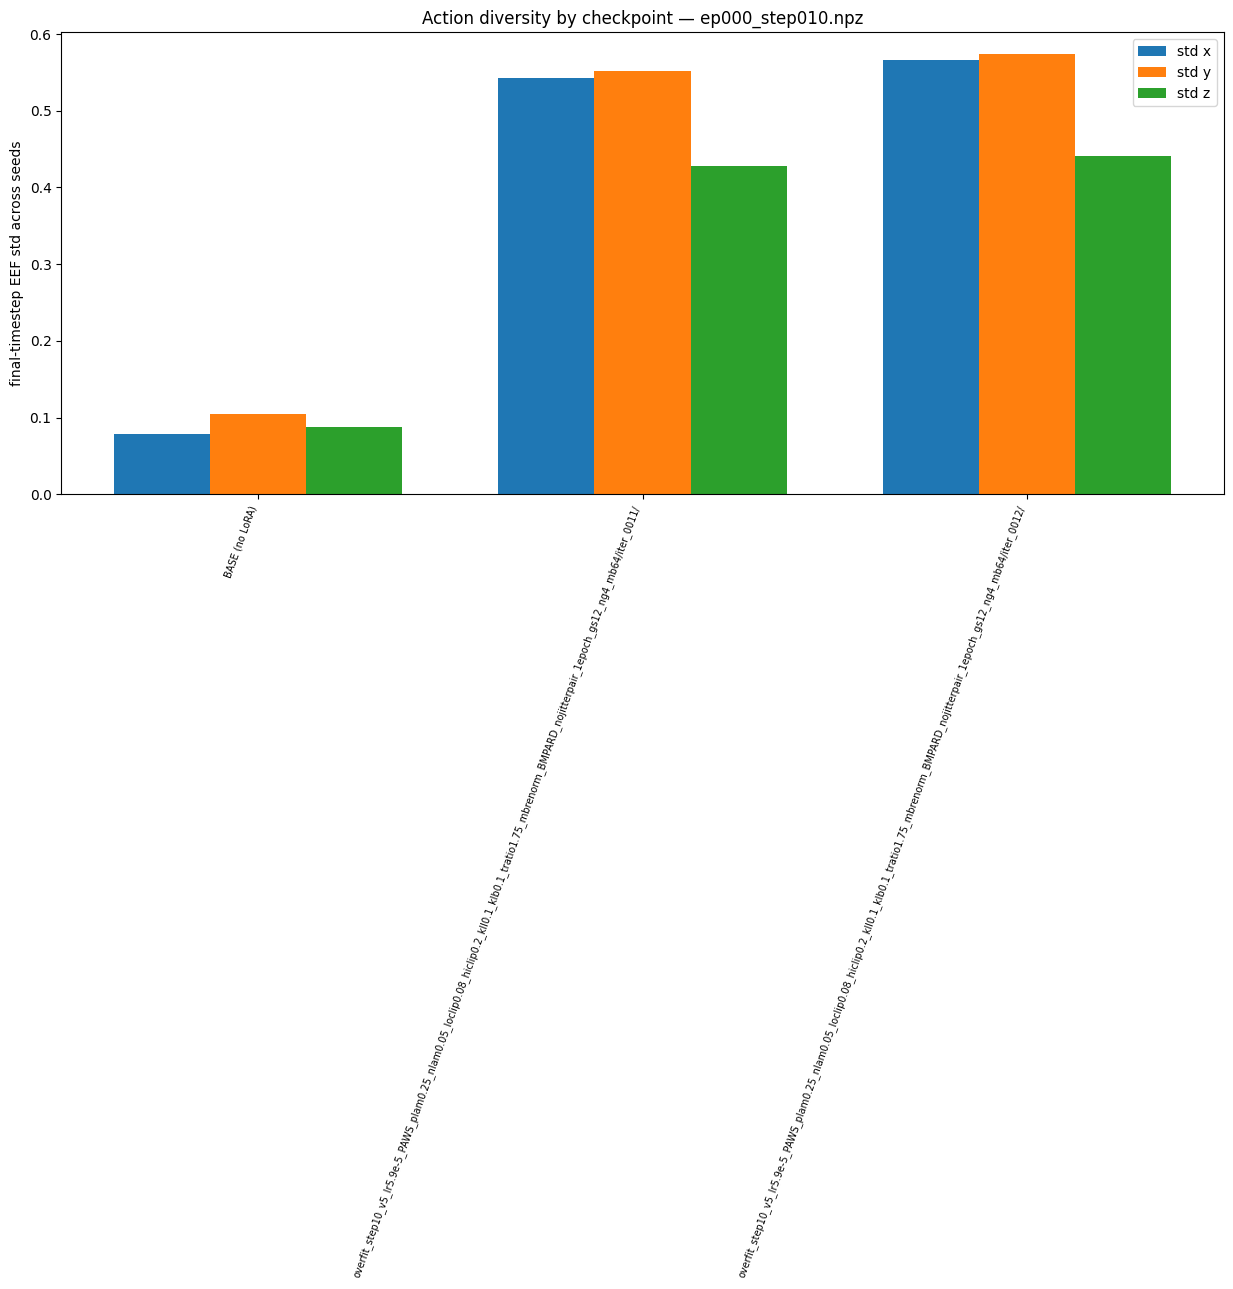

In [7]:
# Cell 6: Cross-checkpoint summary — final-timestep EEF position std across seeds.
labels_short = list(results.keys())
final_std = np.array([results[k]["final_std"] for k in labels_short])  # (n_ckpt, 3)

print(f"{'checkpoint':52s} {'std_x':>8s} {'std_y':>8s} {'std_z':>8s} {'mean':>9s}")
for k, fs in zip(labels_short, final_std):
    print(f"{k:52s} {fs[0]:8.4f} {fs[1]:8.4f} {fs[2]:8.4f} {fs.mean():9.4f}")

x = np.arange(len(labels_short))
w = 0.25
fig, ax = plt.subplots(figsize=(15, 6))
for i, l in enumerate(["x", "y", "z"]):
    ax.bar(x + (i - 1) * w, final_std[:, i], w, label=f"std {l}")
ax.set_xticks(x)
ax.set_xticklabels(labels_short, rotation=70, ha="right", fontsize=7)
ax.set_ylabel("final-timestep EEF std across seeds")
ax.set_title(f"Action diversity by checkpoint — {os.path.basename(OBS_PATH)}")
ax.legend()
plt.tight_layout()
plt.show()

Observation: /home/ubuntu/results/npz_save_CoffeeServeMug_v2/ep000_step012.npz
Task: ('pick the mug from under the coffee machine dispenser and place it on the counter',)


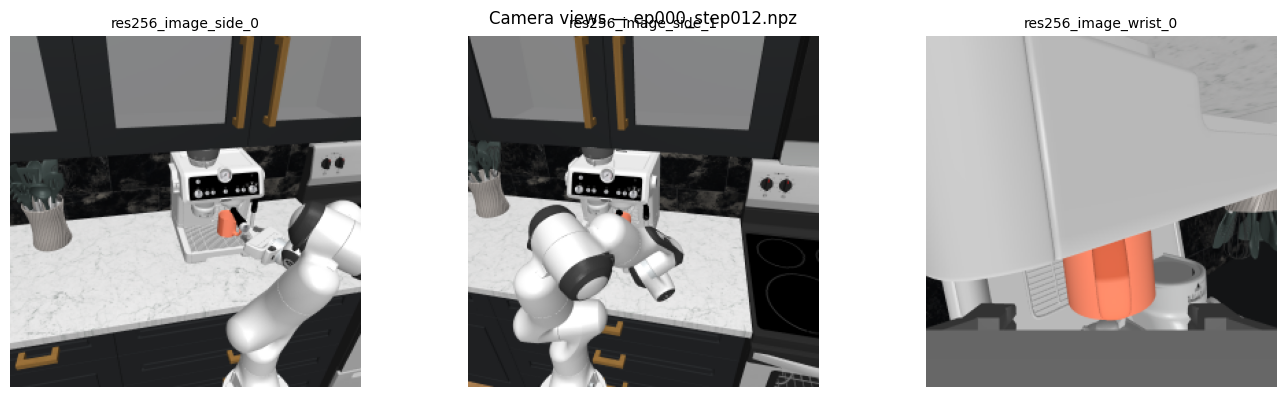

Backbone features: torch.Size([1, 295, 2048])

CHECKPOINT: BASE (no LoRA)


Across all timesteps:
  x: mean=1.6897, 	var=0.0023, 	std=0.0455, 	range=0.2434
  y: mean=0.6733, 	var=0.0234, 	std=0.1338, 	range=0.7270
  z: mean=-0.2346, 	var=0.0117, 	std=0.0873, 	range=0.4611
Across final timestep only:
  x: mean=3.0560, 	var=0.0046, 	std=0.0682, 	range=0.4199
  y: mean=1.4409, 	var=0.0742, 	std=0.2724, 	range=1.6533
  z: mean=-0.8299, 	var=0.0518, 	std=0.2277, 	range=1.2935


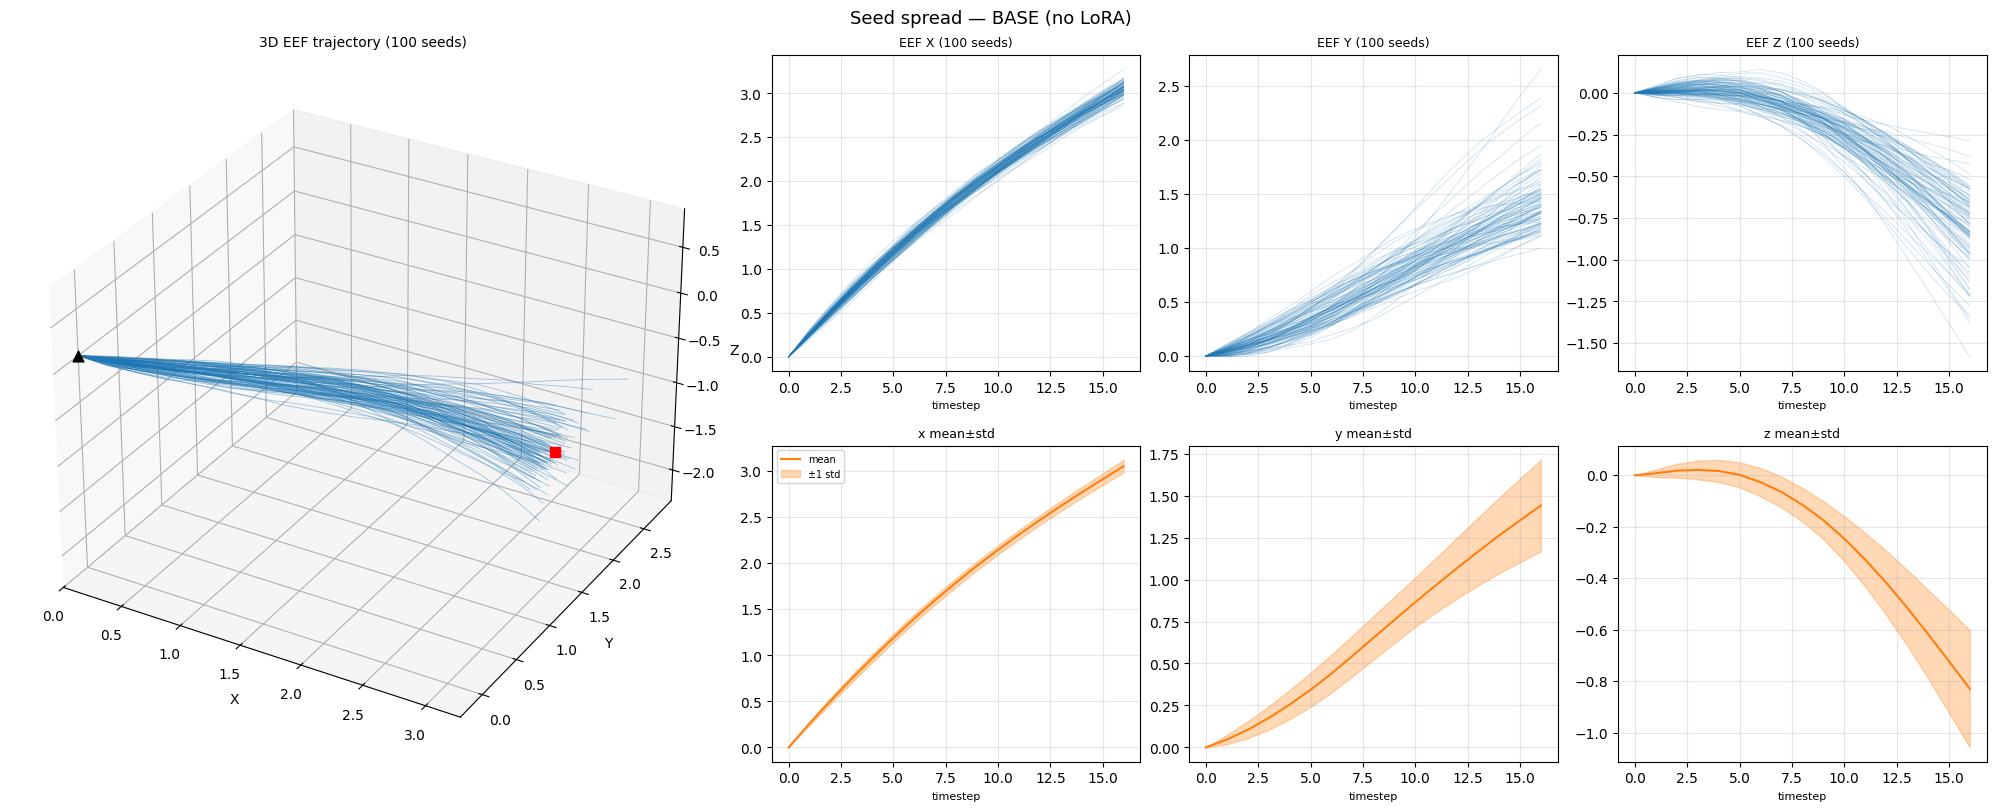


CHECKPOINT: overfit_step10_v5_lr5.9e-5_PAWS_plam0.25_nlam0.05_loclip0.08_hiclip0.2_kll0.1_klb0.1_tratio1.75_mbrenorm_BMPARD_nojitterpair_1epoch_gs12_ng4_mb64/iter_0011/
  Loaded 388 LoRA parameters from /home/ubuntu/my_Isaac-GR00T/grpo_data/overfit_step10_v5_lr5.9e-5_PAWS_plam0.25_nlam0.05_loclip0.08_hiclip0.2_kll0.1_klb0.1_tratio1.75_mbrenorm_BMPARD_nojitterpair_1epoch_gs12_ng4_mb64/iter_0011
Across all timesteps:
  x: mean=2.1079, 	var=0.1036, 	std=0.2897, 	range=1.7805
  y: mean=1.1430, 	var=0.3843, 	std=0.5283, 	range=3.1593
  z: mean=-0.6483, 	var=0.1642, 	std=0.3449, 	range=1.8713
Across final timestep only:
  x: mean=3.9368, 	var=0.2537, 	std=0.5037, 	range=3.2588
  y: mean=2.4814, 	var=1.2692, 	std=1.1266, 	range=6.4526
  z: mean=-1.8604, 	var=0.5643, 	std=0.7512, 	range=4.3475


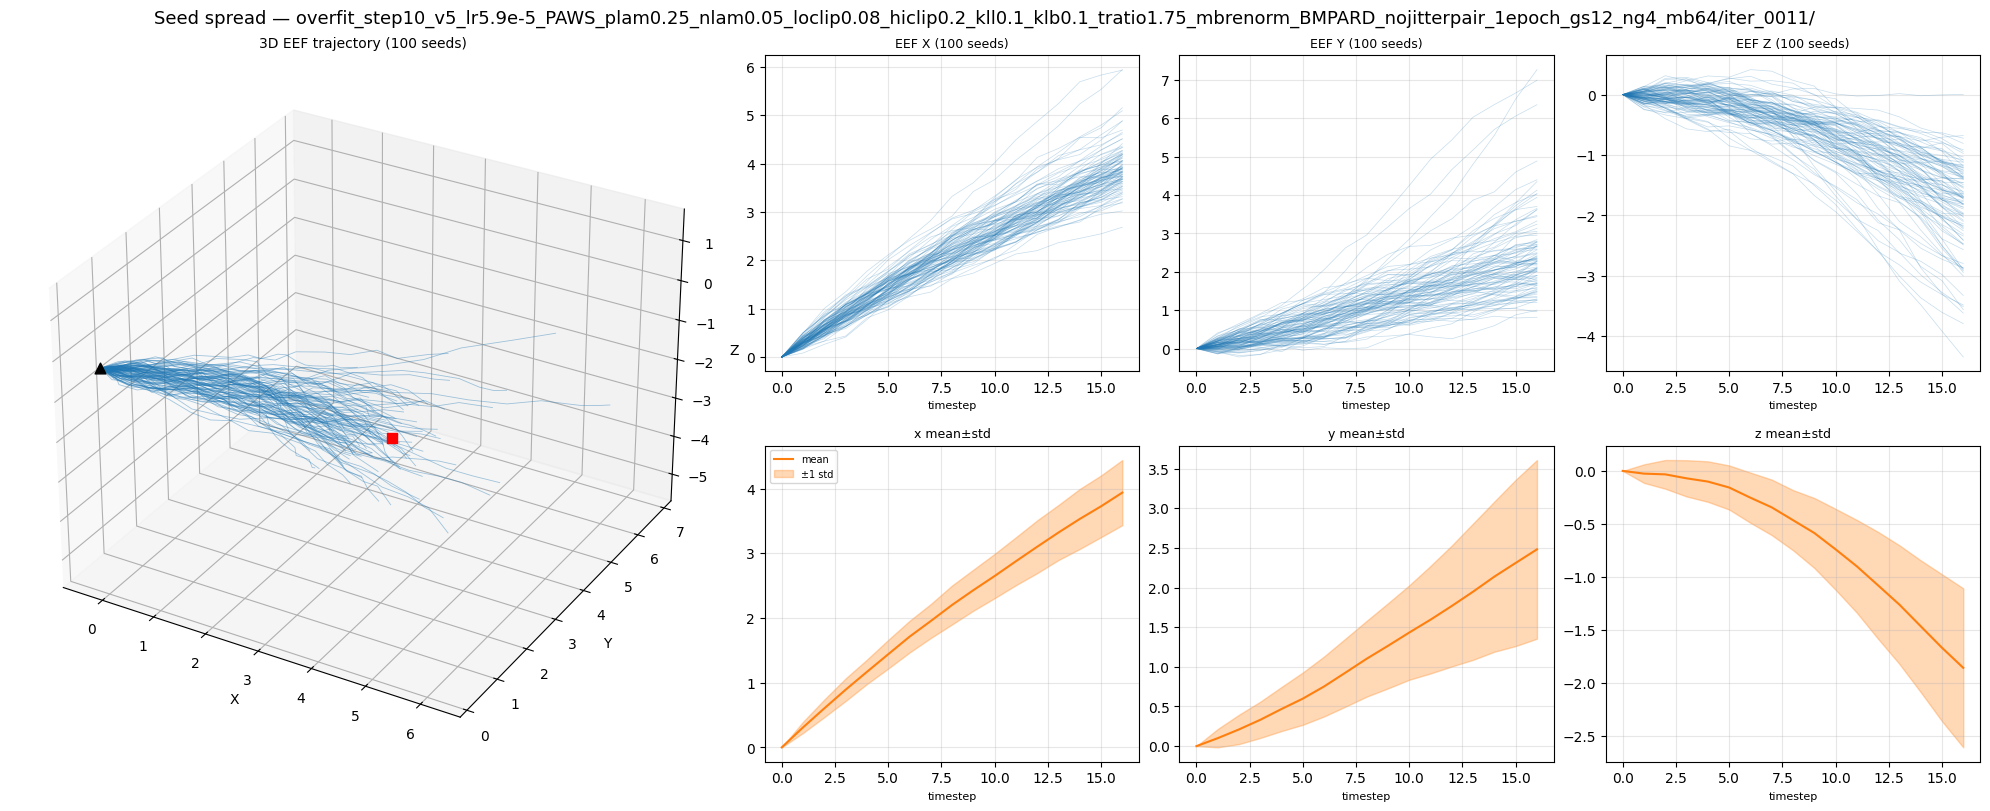


CHECKPOINT: overfit_step10_v5_lr5.9e-5_PAWS_plam0.25_nlam0.05_loclip0.08_hiclip0.2_kll0.1_klb0.1_tratio1.75_mbrenorm_BMPARD_nojitterpair_1epoch_gs12_ng4_mb64/iter_0012/
  Loaded 388 LoRA parameters from /home/ubuntu/my_Isaac-GR00T/grpo_data/overfit_step10_v5_lr5.9e-5_PAWS_plam0.25_nlam0.05_loclip0.08_hiclip0.2_kll0.1_klb0.1_tratio1.75_mbrenorm_BMPARD_nojitterpair_1epoch_gs12_ng4_mb64/iter_0012
Across all timesteps:
  x: mean=2.1323, 	var=0.1142, 	std=0.3035, 	range=1.8658
  y: mean=1.2001, 	var=0.4305, 	std=0.5574, 	range=3.3339
  z: mean=-0.6703, 	var=0.1759, 	std=0.3562, 	range=1.9407
Across final timestep only:
  x: mean=3.9970, 	var=0.2830, 	std=0.5320, 	range=3.4355
  y: mean=2.6242, 	var=1.4342, 	std=1.1976, 	range=6.7429
  z: mean=-1.9255, 	var=0.6075, 	std=0.7794, 	range=4.5458


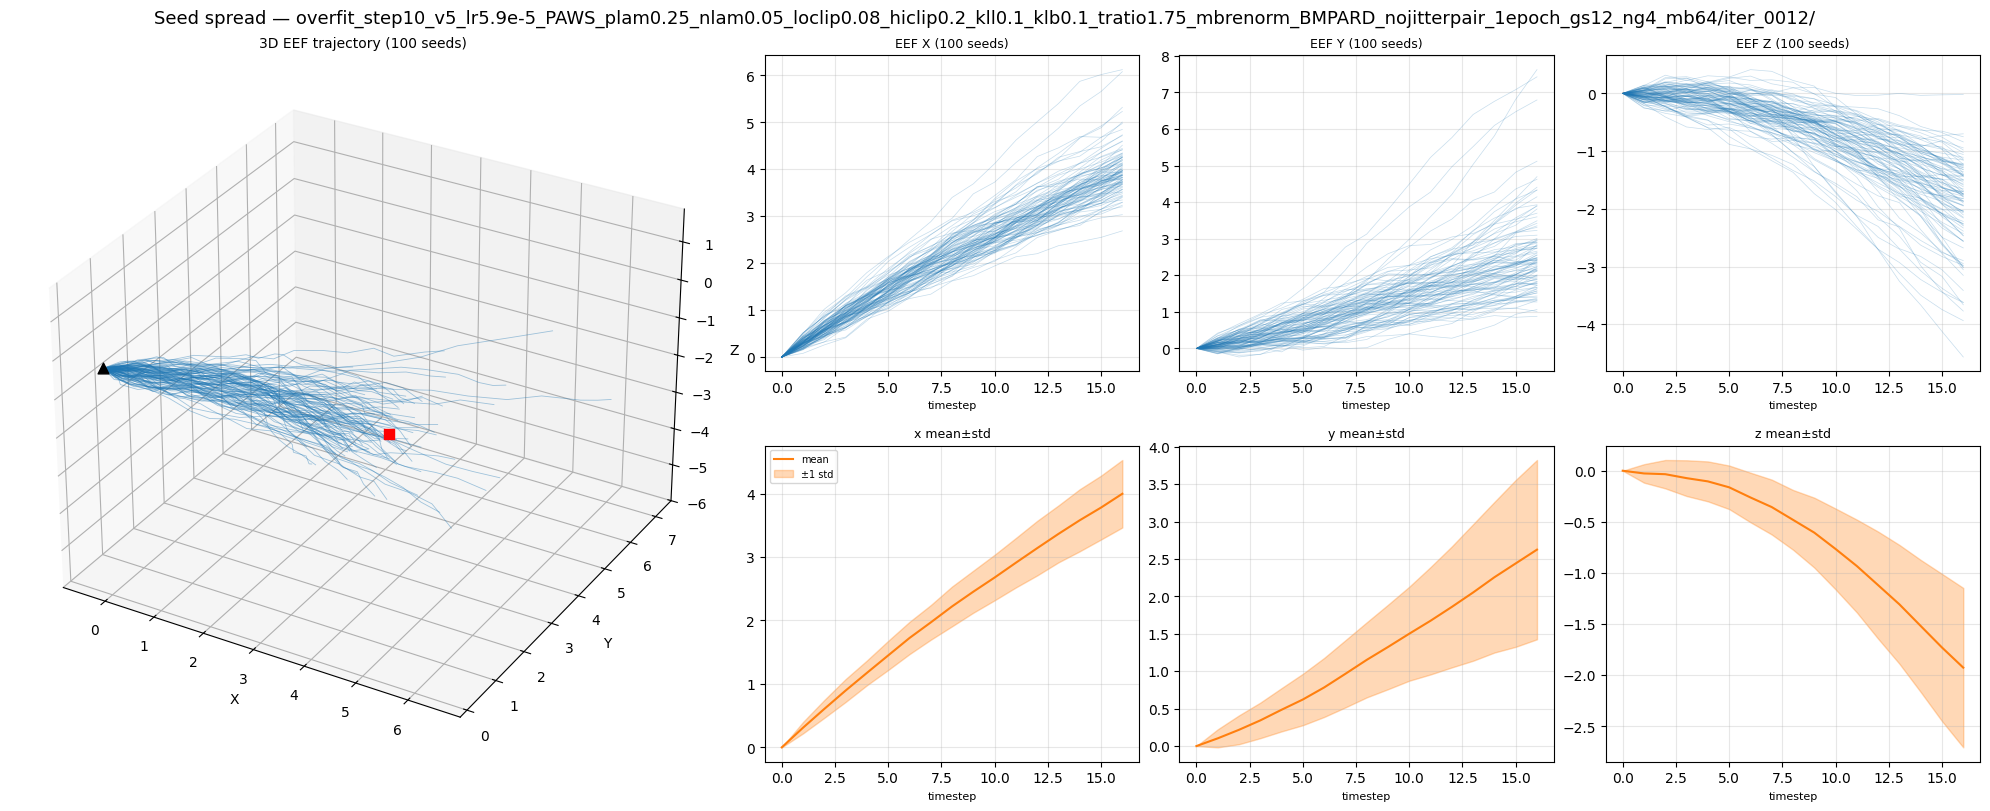

In [8]:
# Cell 7: Re-run the full comparison for a different observation (step 012).
OBS_PATH = "/home/ubuntu/results/npz_save_CoffeeServeMug_v2/ep000_step012.npz"
_features, results = analyze_all_checkpoints(OBS_PATH)

checkpoint                                              std_x    std_y    std_z      mean
BASE (no LoRA)                                         0.0682   0.2724   0.2277    0.1894
overfit_step10_v5_lr5.9e-5_PAWS_plam0.25_nlam0.05_loclip0.08_hiclip0.2_kll0.1_klb0.1_tratio1.75_mbrenorm_BMPARD_nojitterpair_1epoch_gs12_ng4_mb64/iter_0011/   0.5037   1.1266   0.7512    0.7938
overfit_step10_v5_lr5.9e-5_PAWS_plam0.25_nlam0.05_loclip0.08_hiclip0.2_kll0.1_klb0.1_tratio1.75_mbrenorm_BMPARD_nojitterpair_1epoch_gs12_ng4_mb64/iter_0012/   0.5320   1.1976   0.7794    0.8363


/mnt/scratch/tmp/ipykernel_11494/378827261.py:20: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


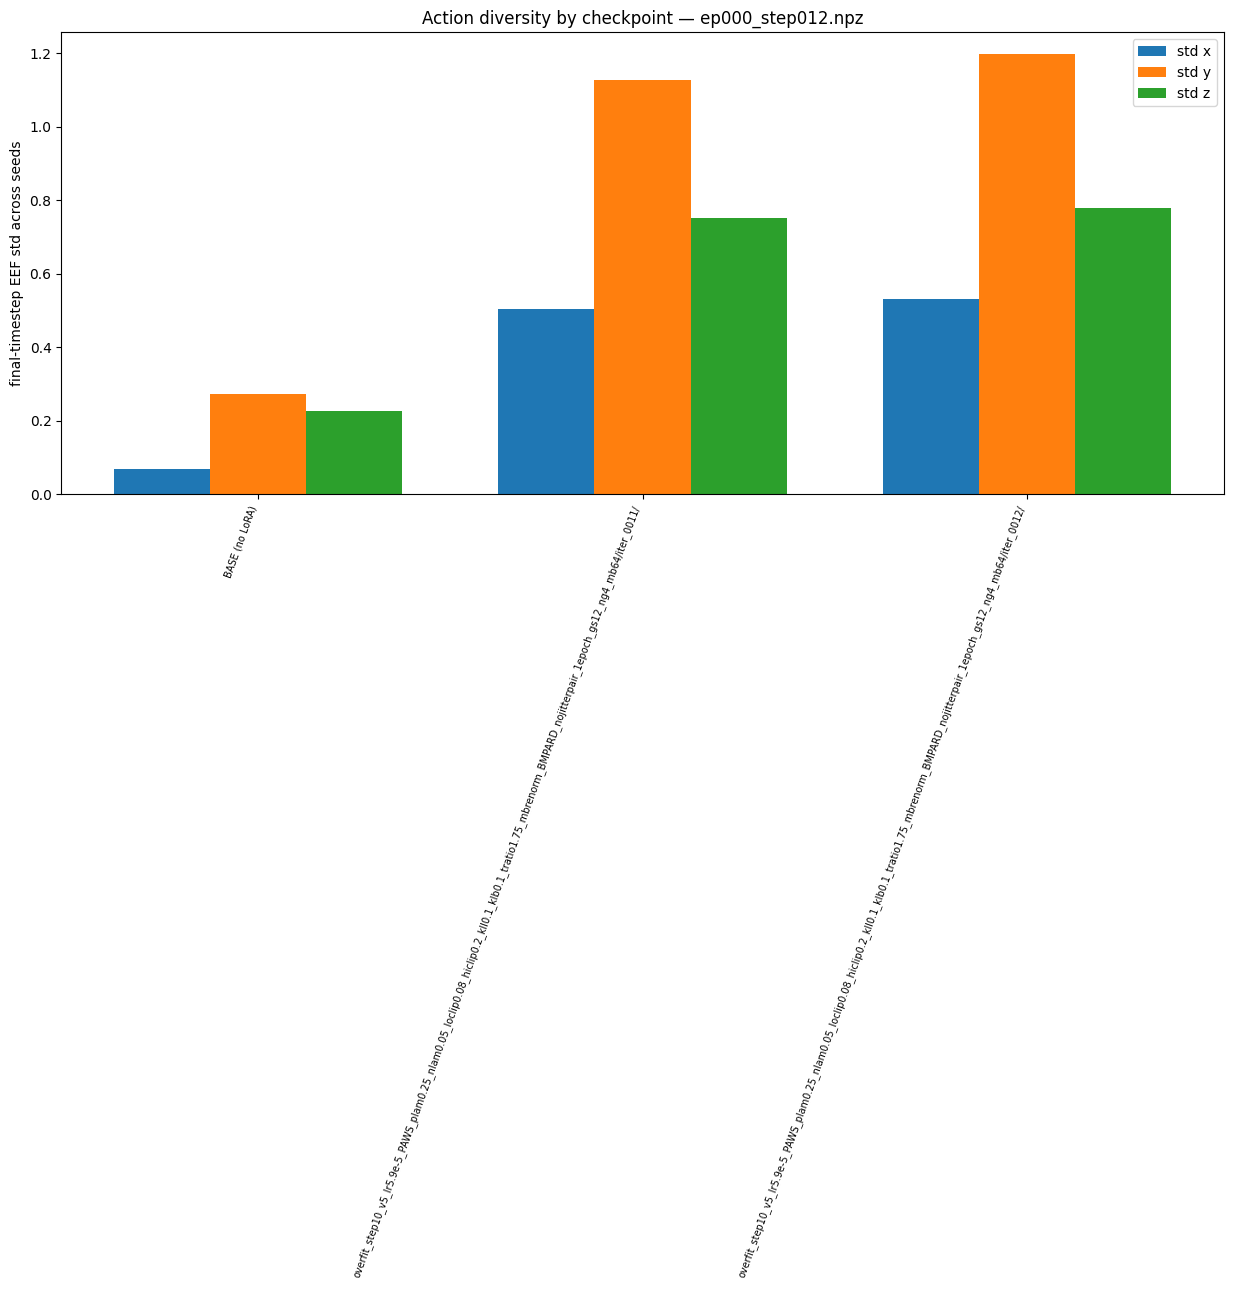

In [9]:
# Cell 8: Cross-checkpoint summary for the step-012 observation
# (identical to Cell 6, re-run against the results from the cell above).
labels_short = list(results.keys())
final_std = np.array([results[k]["final_std"] for k in labels_short])  # (n_ckpt, 3)

print(f"{'checkpoint':52s} {'std_x':>8s} {'std_y':>8s} {'std_z':>8s} {'mean':>9s}")
for k, fs in zip(labels_short, final_std):
    print(f"{k:52s} {fs[0]:8.4f} {fs[1]:8.4f} {fs[2]:8.4f} {fs.mean():9.4f}")

x = np.arange(len(labels_short))
w = 0.25
fig, ax = plt.subplots(figsize=(15, 6))
for i, l in enumerate(["x", "y", "z"]):
    ax.bar(x + (i - 1) * w, final_std[:, i], w, label=f"std {l}")
ax.set_xticks(x)
ax.set_xticklabels(labels_short, rotation=70, ha="right", fontsize=7)
ax.set_ylabel("final-timestep EEF std across seeds")
ax.set_title(f"Action diversity by checkpoint — {os.path.basename(OBS_PATH)}")
ax.legend()
plt.tight_layout()
plt.show()